#### Loading dataset

In [11]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pylab as plt
import random
import datetime
from  pathlib import Path

print("tf", tf.__version__, "| tf.keras ->", tf.keras.__name__)

tf 2.21.0 | tf.keras -> tensorflow.keras


In [12]:
seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
#Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

#### An overview of the images

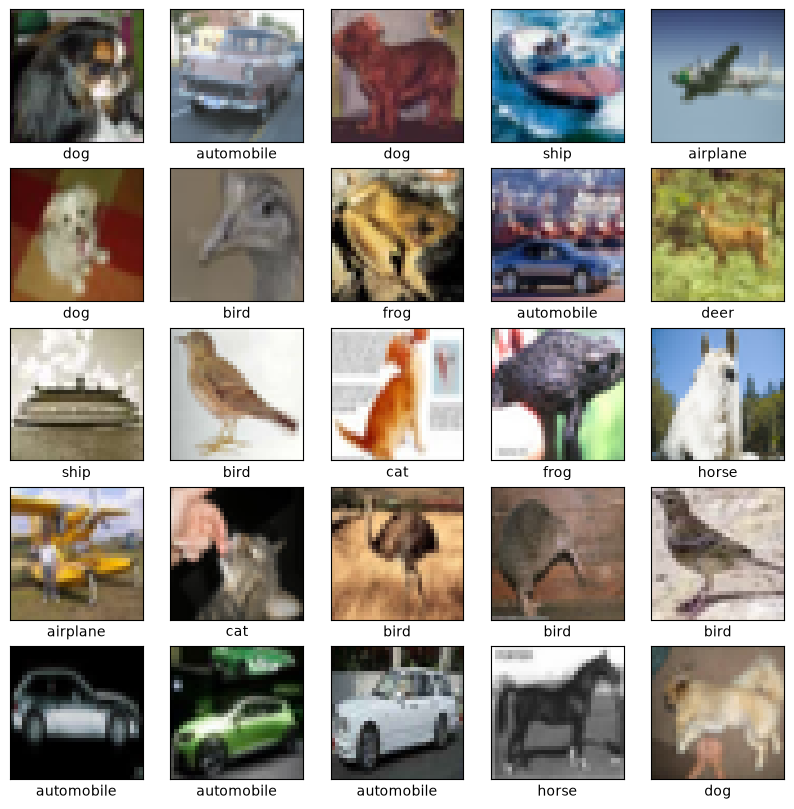

In [13]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

train_idx = list(range(len(train_labels)))

random.seed(1)
random_sample = random.sample(train_idx, 25)

plt.figure(figsize=(10,10))
for i in range(len(random_sample)):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[random_sample[i]], cmap=plt.cm.binary)
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[random_sample[i]][0]])
plt.show()

### Build, compile and train the model

In [14]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((test_images[:5000], test_labels[:5000]))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images[5000:], test_labels[5000:]))

TRAIN_DATASET_SIZE = len(train_dataset)
print(f"Training data sample size: {TRAIN_DATASET_SIZE}")
VALIDATION_DATASET_SIZE = len(validation_dataset)
print(f"Validation data sample size: {VALIDATION_DATASET_SIZE}")
TEST_DATASET_SIZE = len(test_dataset)
print(f"Test data sample size: {TEST_DATASET_SIZE}")

BATCH_SIZE = 128 # Each batch will have 128 images and labels

# Each training batch is fed into the model during the training process to enable incremental updates to weights and biases.

train_dataset = train_dataset.shuffle(buffer_size=TRAIN_DATASET_SIZE).batch(BATCH_SIZE, drop_remainder=True)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

Training data sample size: 50000
Validation data sample size: 5000
Test data sample size: 5000


In [15]:
#Model build - define the model

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', kernel_initializer = 'glorot_uniform', padding = 'same',input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', kernel_initializer = 'glorot_uniform', padding = 'same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu', kernel_initializer = 'glorot_uniform'),
    tf.keras.layers.Dense(10, activation='softmax', name = 'custom_class')
])
model.build([None, 32, 32, 3])

In [16]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Model Checkpoint

In [17]:
CHECKPOINT_DIR = './cifar10_training_checkpoints'
CHECKPOINT_PREFIX = os.path.join(CHECKPOINT_DIR, "ckpt_{epoch}")
CHECKPOINT_PREFIX

'./cifar10_training_checkpoints/ckpt_{epoch}'

In [18]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=CHECKPOINT_PREFIX,
                                                 monitor='val_accuracy',
                                                 mode='max',)

Now, when you launch a training process with callback then the callback will expect a python list. So, let's put the checkpoint object into a
python list

In [19]:
callbacks = [checkpoint]

In [20]:
hist = model.fit(train_dataset, epochs=10, validation_data=validation_dataset, callbacks=callbacks).history
hist

Epoch 1/10
390/390 [==============================] - ETA: 0s - loss: 1.9625 - accuracy: 0.2774INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_1/assets


INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_1/assets


390/390 [==============================] - 11s 27ms/step - loss: 1.9625 - accuracy: 0.2774 - val_loss: 1.6683 - val_accuracy: 0.3866
Epoch 2/10
389/390 [============================>.] - ETA: 0s - loss: 1.5405 - accuracy: 0.4444INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_2/assets


INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_2/assets


390/390 [==============================] - 12s 31ms/step - loss: 1.5403 - accuracy: 0.4446 - val_loss: 1.4882 - val_accuracy: 0.4708
Epoch 3/10
390/390 [==============================] - ETA: 0s - loss: 1.4003 - accuracy: 0.5008INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_3/assets


...

INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_9/assets


390/390 [==============================] - 11s 29ms/step - loss: 0.9602 - accuracy: 0.6676 - val_loss: 1.3037 - val_accuracy: 0.5850
Epoch 10/10
390/390 [==============================] - ETA: 0s - loss: 0.9020 - accuracy: 0.6905INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_10/assets


INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_10/assets


390/390 [==============================] - 11s 27ms/step - loss: 0.9020 - accuracy: 0.6905 - val_loss: 1.3784 - val_accuracy: 0.5882


{'loss': [1.962548851966858,
  1.5403074026107788,
  1.4002991914749146,
  1.2977325916290283,
  1.2467509508132935,
  1.154450535774231,
  1.0821152925491333,
  1.0232040882110596,
  0.9601971507072449,
  0.9019668102264404],
 'accuracy': [0.2774238884449005,
  0.4445512890815735,
  0.5008212924003601,
  0.5427884459495544,
  0.5638020634651184,
  0.5968349575996399,
  0.6245192289352417,
  0.6439703702926636,
  0.6676082015037537,
  0.690504789352417],
 'val_loss': [1.668265461921692,
  1.488155722618103,
  1.359297513961792,
  1.3381192684173584,
  1.271370768547058,
  1.3228106498718262,
  1.228407859802246,
  1.2854241132736206,
  1.3036795854568481,
  1.378448247909546],
 'val_accuracy': [0.38659998774528503,
  0.4708000123500824,
  0.5076000094413757,
  0.526199996471405,
  0.5618000030517578,
  0.5550000071525574,
  0.5842000246047974,
  0.5830000042915344,
  0.5849999785423279,
  0.5881999731063843]}

In [21]:
len(validation_dataset)

40

In [22]:
max_epoch = hist['val_accuracy'].index(max(hist['val_accuracy'])) + 1
max_epoch

10

In [23]:
print(f"The best model is at epoch {max_epoch} with validation accuracy of {hist['val_accuracy'][max_epoch-1]:.4f}")

The best model is at epoch 10 with validation accuracy of 0.5882


In [24]:
!ls -lrt ./cifar10_training_checkpoints

total 0
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:10 ckpt_1
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:11 ckpt_2
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:11 ckpt_3
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:11 ckpt_4
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:11 ckpt_5
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:11 ckpt_6
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:12 ckpt_7
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:12 ckpt_8
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:12 ckpt_9
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:12 ckpt_10


In [25]:
!ls -lrt ./cifar10_training_checkpoints/ckpt_10

total 272
drwxr-xr-x@ 2 ankit  staff      64 Aug 12 21:23 assets
drwxr-xr-x@ 4 ankit  staff     128 Aug 12 23:12 variables
-rw-r--r--@ 1 ankit  staff  115820 Aug 12 23:12 saved_model.pb
-rw-r--r--@ 1 ankit  staff      97 Aug 12 23:12 fingerprint.pb
-rw-r--r--@ 1 ankit  staff   16214 Aug 12 23:12 keras_metadata.pb


In [26]:
BEST_CHECKPOINT_DIR = './cifar10_best_training_checkpoints'
BEST_CHECKPOINT_PREFIX = os.path.join(BEST_CHECKPOINT_DIR, "ckpt_{epoch}")

best_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_CHECKPOINT_PREFIX,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
)
best_callbacks = [best_checkpoint]
best_hist = model.fit(train_dataset, epochs=10, validation_data=validation_dataset, callbacks=best_callbacks).history

Epoch 1/10
389/390 [============================>.] - ETA: 0s - loss: 0.8728 - accuracy: 0.7024INFO:tensorflow:Assets written to: ./cifar10_best_training_checkpoints/ckpt_1/assets


INFO:tensorflow:Assets written to: ./cifar10_best_training_checkpoints/ckpt_1/assets


390/390 [==============================] - 12s 30ms/step - loss: 0.8730 - accuracy: 0.7023 - val_loss: 1.4347 - val_accuracy: 0.5820
Epoch 2/10
390/390 [==============================] - 11s 28ms/step - loss: 0.8422 - accuracy: 0.7147 - val_loss: 1.5978 - val_accuracy: 0.5520
Epoch 3/10
390/390 [==============================] - 11s 29ms/step - loss: 0.7610 - accuracy: 0.7392 - val_loss: 1.5099 - val_accuracy: 0.5718
Epoch 4/10
390/390 [==============================] - 12s 30ms/step - loss: 0.7475 - accuracy: 0.7493 - val_loss: 1.6731 - val_accuracy: 0.5620
Epoch 5/10
390/390 [==============================] - 11s 29ms/step - loss: 0.6965 - accuracy: 0.7671 - val_loss: 1.7341 - val_accuracy: 0.5798
Epoch 6/10
390/390 [==============================] - 12s 30ms/step - loss: 0.7184 - accuracy: 0.7633 - val_loss: 1.8521 - val_accuracy: 0.5680
Epoch 7/10
390/390 [==============================] - 12s 31ms/step - loss: 0.6416 - accuracy: 0.7900 - val_loss: 1.8440 - val_accuracy: 0.5578
Epo

In [27]:
!ls -lrt ./cifar10_best_training_checkpoints

total 0
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 21:34 ckpt_2
drwxr-xr-x@ 7 ankit  staff  224 Aug 12 23:12 ckpt_1


### Early Stopping

The Early stopping callback object enables you to stop the training process before it reaches the final epoch. Usually you do this to save training time if the model is not improving. So, we track a certain metric, say validation accuracy and if this does not improve after a certain number of epochs, the training will stop. 

In [28]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
# It means if validation accuracy does not improve within 3 consecutive epochs, the training will stop early to prevent overfitting and save time.
callbacks = [checkpoint, early_stop]
hist = model.fit(train_dataset, epochs=15, validation_data=validation_dataset, callbacks=callbacks).history

Epoch 1/15


390/390 [==============================] - ETA: 0s - loss: 0.7031 - accuracy: 0.7834INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_1/assets


INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_1/assets


390/390 [==============================] - 12s 31ms/step - loss: 0.7031 - accuracy: 0.7834 - val_loss: 2.1851 - val_accuracy: 0.5404
Epoch 2/15
389/390 [============================>.] - ETA: 0s - loss: 0.6240 - accuracy: 0.8054INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_2/assets


INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_2/assets


...

390/390 [==============================] - 12s 31ms/step - loss: 0.6507 - accuracy: 0.8015 - val_loss: 2.2804 - val_accuracy: 0.5202
Epoch 4/15
389/390 [============================>.] - ETA: 0s - loss: 0.6624 - accuracy: 0.8010INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_4/assets


INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_4/assets


390/390 [==============================] - 13s 33ms/step - loss: 0.6625 - accuracy: 0.8009 - val_loss: 2.8109 - val_accuracy: 0.5302
Epoch 5/15
390/390 [==============================] - ETA: 0s - loss: 0.6302 - accuracy: 0.8098INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_5/assets


INFO:tensorflow:Assets written to: ./cifar10_training_checkpoints/ckpt_5/assets


390/390 [==============================] - 13s 34ms/step - loss: 0.6302 - accuracy: 0.8098 - val_loss: 2.5551 - val_accuracy: 0.5388


### Tensorboard

Tensorboard provides a visual representation of how model parameters evolve throughout the training cycle. It's often used for training model accuracy over training epochs.     
     
Tensorboard can also let you see how weights and biases evolve in each model layer. And just like Model checkpoint and early stopping, Tensorboard is applied to the training process via the callbacks module. 

In [35]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pylab as plt
import random
import datetime
from  pathlib import Path

print("tf", tf.__version__, "| tf.keras ->", tf.keras.__name__)

tf 2.21.0 | tf.keras -> tensorflow.keras


In [36]:
seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
#Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

In [37]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((test_images[:5000], test_labels[:5000]))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images[5000:], test_labels[5000:]))

TRAIN_DATASET_SIZE = len(train_dataset)
print(f"Training data sample size: {TRAIN_DATASET_SIZE}")
VALIDATION_DATASET_SIZE = len(validation_dataset)
print(f"Validation data sample size: {VALIDATION_DATASET_SIZE}")
TEST_DATASET_SIZE = len(test_dataset)
print(f"Test data sample size: {TEST_DATASET_SIZE}")

BATCH_SIZE = 128 # Each batch will have 128 images and labels

# Each training batch is fed into the model during the training process to enable incremental updates to weights and biases.

train_dataset = train_dataset.shuffle(buffer_size=TRAIN_DATASET_SIZE).batch(BATCH_SIZE, drop_remainder=True)
validation_dataset = validation_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

Training data sample size: 50000
Validation data sample size: 5000
Test data sample size: 5000


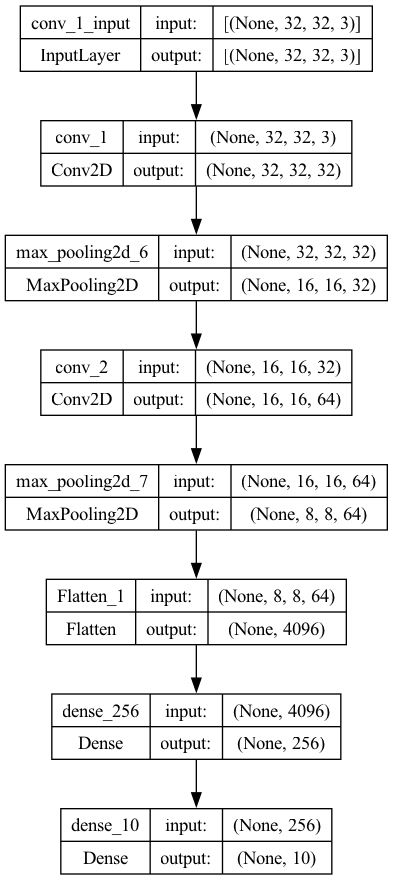

In [38]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu',name='conv_1', 
                           kernel_initializer = 'glorot_uniform', padding = 'same',input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu',name='conv_2', 
                           kernel_initializer = 'glorot_uniform', padding = 'same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(name = 'Flatten_1'),
    tf.keras.layers.Dense(256, activation='relu', kernel_initializer = 'glorot_uniform',name='dense_256'),
    tf.keras.layers.Dense(10, activation='softmax', name = 'dense_10')
])
model.build([None, 32, 32, 3])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
tf.keras.utils.plot_model(model, show_shapes=True)

In [39]:
MODEL_NAME = f'CIFAR10-{datetime.datetime.now():%Y%m%d-%H%M%S}'

CHECKPOINT_DIR = './' + MODEL_NAME
CHECKPOINT_PREFIX = os.path.join(CHECKPOINT_DIR, "ckpt_{epoch}")

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath = CHECKPOINT_PREFIX,
    monitor = 'val_accuracy',
    mode = 'max',
)

tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir = f'./tensorboardlogs/{MODEL_NAME}',
    write_graph = True, # to visualize model graph
    write_images = True, # ensures model weights written un the logs, so that you can visualize during training
    histogram_freq=1 # it tells tensorboard when to create a visualization by epoch. freq=1 means visualization is created for each epoch.
)

In [41]:
callbacks = [checkpoint,tensorboard]
hist = model.fit(train_dataset,epochs=25,validation_data=validation_dataset,callbacks=callbacks).history

Epoch 1/25
388/390 [============================>.] - ETA: 0s - loss: 1.7030 - accuracy: 0.3813INFO:tensorflow:Assets written to: ./CIFAR10-20260812-231710/ckpt_1/assets


INFO:tensorflow:Assets written to: ./CIFAR10-20260812-231710/ckpt_1/assets


390/390 [==============================] - 11s 27ms/step - loss: 1.7022 - accuracy: 0.3815 - val_loss: 1.3934 - val_accuracy: 0.4988
Epoch 2/25
390/390 [==============================] - ETA: 0s - loss: 1.3262 - accuracy: 0.5275INFO:tensorflow:Assets written to: ./CIFAR10-20260812-231710/ckpt_2/assets


INFO:tensorflow:Assets written to: ./CIFAR10-20260812-231710/ckpt_2/assets


390/390 [==============================] - 11s 27ms/step - loss: 1.3262 - accuracy: 0.5275 - val_loss: 1.2182 - val_accuracy: 0.5708
Epoch 3/25
390/390 [==============================] - ETA: 0s - loss: 1.1864 - accuracy: 0.5837INFO:tensorflow:Assets written to: ./CIFAR10-20260812-231710/ckpt_3/assets


...

390/390 [==============================] - 12s 31ms/step - loss: 0.6052 - accuracy: 0.8396 - val_loss: 2.7207 - val_accuracy: 0.5462
Epoch 24/25
389/390 [============================>.] - ETA: 0s - loss: 0.6874 - accuracy: 0.8187INFO:tensorflow:Assets written to: ./CIFAR10-20260812-231710/ckpt_24/assets


INFO:tensorflow:Assets written to: ./CIFAR10-20260812-231710/ckpt_24/assets


390/390 [==============================] - 12s 32ms/step - loss: 0.6874 - accuracy: 0.8186 - val_loss: 2.8706 - val_accuracy: 0.5242
Epoch 25/25
390/390 [==============================] - ETA: 0s - loss: 0.6301 - accuracy: 0.8323INFO:tensorflow:Assets written to: ./CIFAR10-20260812-231710/ckpt_25/assets


INFO:tensorflow:Assets written to: ./CIFAR10-20260812-231710/ckpt_25/assets


390/390 [==============================] - 12s 31ms/step - loss: 0.6301 - accuracy: 0.8323 - val_loss: 3.0215 - val_accuracy: 0.5506


In [44]:
%reload_ext tensorboard

In [45]:
%tensorboard --logdir ./tensorboardlogs

Reusing TensorBoard on port 6006 (pid 92648), started 0:01:06 ago. (Use '!kill 92648' to kill it.)

we can see clear sign of overfitting here. Histogram tab helps to see the distributions like normal distribution etc.